In [1]:
# Code to read csv file into colaboratory:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [2]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
#click the output link and allow it to get a access code, copy paste it in the box and press enter

In [3]:
#2.1 Get the file
downloaded = drive.CreateFile({'id':'1ejGB9xIZrKYJhw7YOiLTc-jmtzqixcZg'}) # replace the id with id of file you want to access
downloaded.GetContentFile('Updated Leeds center air quality data 2020.csv') 

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/optimizer_v2/optimizer_v2.py:375: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


Epoch 1/40
1406/1406 [==============================] - 12s 5ms/step - loss: 0.0053 - accuracy: 3.8626e-05 - val_loss: 0.0025 - val_accuracy: 0.0000e+00
Epoch 2/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0033 - accuracy: 1.6583e-04 - val_loss: 0.0022 - val_accuracy: 0.0000e+00
Epoch 3/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0027 - accuracy: 1.2247e-04 - val_loss: 0.0019 - val_accuracy: 0.0000e+00
Epoch 4/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0023 - accuracy: 7.3470e-04 - val_loss: 0.0015 - val_accuracy: 0.0000e+00
Epoch 5/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0017 - accuracy: 8.4172e-04 - val_loss: 0.0012 - val_accuracy: 0.0000e+00
Epoch 6/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0015 - accuracy: 6.3609e-04 - val_loss: 0.0011 - val_accuracy: 0.0000e+00
Epoch 7/40
1406/1406 [==============================] - 6s 4ms/step - loss: 0.0012 - ac

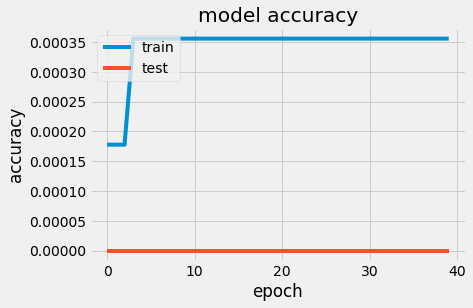

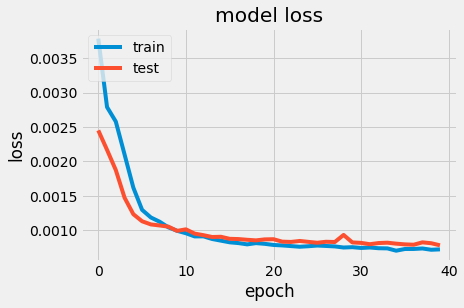

In [ ]:
#LSTM
#Import the libraries
import math
import numpy as np
import pandas as pd
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.layers import Dropout
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
#print(dataset.head())
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
#dataset_x = dataset.drop(['End Date', 'End Time', ' PM25'], axis=1)
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

#Scale the all of the data to be values between 0 and 1 
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(x_train)
scaled_ytrain = y_scaler.fit_transform(y_train)
scaled_xtest = x_scaler.fit_transform(x_test)
#scaled_ytest = scaler.fit_transform(y_test)

#Convert to numpy arrays
scaled_xtrain, scaled_ytrain = np.array(scaled_xtrain), np.array(scaled_ytrain)

#Reshape the data into 3-D array
scaled_x = np.reshape(scaled_xtrain, (scaled_xtrain.shape[0],scaled_xtrain.shape[1],1))
scaled_y = np.reshape(scaled_ytrain, (scaled_ytrain.shape[0],scaled_ytrain.shape[1],1))

# Initialising the RNN
model_lstm = Sequential()

model_lstm.add(LSTM(units = 100, return_sequences = False, input_shape = (scaled_x.shape[1], 1)))
model_lstm.add(Dropout(0.2))

# Adding a second LSTM layer and Dropout layer
#model_lstm.add(LSTM(units = 100, return_sequences = True))
#model_lstm.add(Dropout(0.2))

# Adding a third LSTM layer and Dropout layer
#model.add(LSTM(units = 100, return_sequences = True))
#model.add(Dropout(0.2))

# Adding a fourth LSTM layer and and Dropout layer
#model_lstm.add(LSTM(units = 30))
#model_lstm.add(Dropout(0.3))

# Adding the output layer
# For Full connection layer we use dense
# As the output is 1D so we use unit=1
model_lstm.add(Dense(units = 1))

#compile and fit the model on 40 epochs
optimizer = keras.optimizers.Adam(lr=0.0001)
model_lstm.compile(optimizer = optimizer, loss = 'mean_squared_error', metrics=['accuracy'])
lstm_history = model_lstm.fit(scaled_x, scaled_y, epochs = 40, batch_size = 4, shuffle=True, validation_split=0.20)

#Convert x_test to a numpy array 
x_test = np.array(scaled_xtest)

#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

#check predicted values
predictions = model_lstm.predict(x_test)
x_pred = model_lstm.predict(scaled_x)
#Undo scaling
predictions = y_scaler.inverse_transform(predictions)
x_pred = y_scaler.inverse_transform(x_pred)
#print(predictions.shape)
#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)

# list all data in history
print(lstm_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/optimizer_v2/optimizer_v2.py:375: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


Epoch 1/40
1406/1406 [==============================] - 12s 6ms/step - loss: 0.0048 - accuracy: 4.9359e-04 - val_loss: 0.0023 - val_accuracy: 0.0000e+00
Epoch 2/40
1406/1406 [==============================] - 8s 5ms/step - loss: 0.0026 - accuracy: 5.1348e-04 - val_loss: 0.0019 - val_accuracy: 0.0000e+00
Epoch 3/40
1406/1406 [==============================] - 8s 6ms/step - loss: 0.0023 - accuracy: 2.4846e-04 - val_loss: 0.0017 - val_accuracy: 0.0000e+00
Epoch 4/40
1406/1406 [==============================] - 8s 6ms/step - loss: 0.0021 - accuracy: 7.9274e-04 - val_loss: 0.0014 - val_accuracy: 0.0000e+00
Epoch 5/40
1406/1406 [==============================] - 8s 6ms/step - loss: 0.0019 - accuracy: 2.8329e-04 - val_loss: 0.0012 - val_accuracy: 0.0000e+00
Epoch 6/40
1406/1406 [==============================] - 7s 5ms/step - loss: 0.0015 - accuracy: 7.4483e-04 - val_loss: 0.0011 - val_accuracy: 0.0000e+00
Epoch 7/40
1406/1406 [==============================] - 8s 6ms/step - loss: 0.0011 - ac

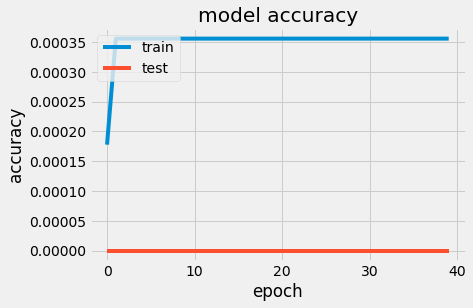

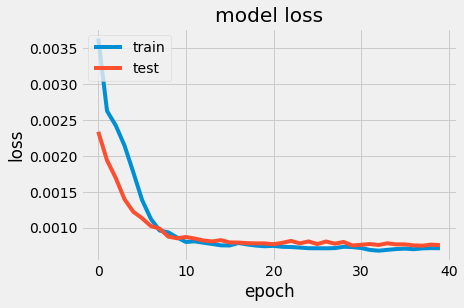

In [ ]:
#GRU
import pandas as pd
import numpy as np
import keras
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import GRU
import tensorflow as tf
from datetime import datetime

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
#print(dataset.head())
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
#dataset_x = dataset.drop(['End Date', 'End Time', ' PM25'], axis=1)
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2, random_state=42)

#Scale the all of the data to be values between 0 and 1 
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
scaled_xtrain = x_scaler.fit_transform(x_train)
scaled_ytrain = y_scaler.fit_transform(y_train)
scaled_xtest = x_scaler.fit_transform(x_test)
#scaled_ytest = scaler.fit_transform(y_test)

#Convert to numpy arrays
scaled_xtrain, scaled_ytrain = np.array(scaled_xtrain), np.array(scaled_ytrain)

#Reshape the data into 3-D array
scaled_x = np.reshape(scaled_xtrain, (scaled_xtrain.shape[0],scaled_xtrain.shape[1],1))
scaled_y = np.reshape(scaled_ytrain, (scaled_ytrain.shape[0],scaled_ytrain.shape[1],1))

model_gru = Sequential()
model_gru.add(GRU(100, return_sequences = False, input_shape = (scaled_x.shape[1], 1)))
model_gru.add(Dropout(0.25))
#model_gru.add(GRU(units=50, return_sequences=True))
#model_gru.add(Dropout(0.2))
#model_gru.add(GRU(units=10))
#model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=1))

#model_gru.compile(loss='mae', optimizer='adam')
#model_gru.summary()
#compile and fit the model
optimizer = keras.optimizers.Adam(lr=0.0001)
model_gru.compile(optimizer = optimizer, loss = 'mean_squared_error', metrics=['accuracy'])
gru_history = model_gru.fit(scaled_x, scaled_y, epochs = 40, batch_size = 4, shuffle=True, validation_split=0.2)

#Convert x_test to a numpy array 
x_test = np.array(scaled_xtest)

#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

#check predicted values
predictions = model_gru.predict(x_test)
x_pred = model_gru.predict(scaled_x)
#Undo scaling
predictions = y_scaler.inverse_transform(predictions)
x_pred = y_scaler.inverse_transform(x_pred)
#print(predictions.shape)
#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)

# list all data in history
print(gru_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(gru_history.history['accuracy'])
plt.plot(gru_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Epoch 1/1000
176/176 [==============================] - 2s 4ms/step - loss: 35.8530 - accuracy: 8.0521e-05 - val_loss: 9.3293 - val_accuracy: 0.0000e+00
Epoch 2/1000
176/176 [==============================] - 0s 2ms/step - loss: 8.1700 - accuracy: 3.7268e-04 - val_loss: 7.2620 - val_accuracy: 0.0000e+00
Epoch 3/1000
176/176 [==============================] - 0s 2ms/step - loss: 8.4176 - accuracy: 6.4847e-04 - val_loss: 6.9751 - val_accuracy: 0.0000e+00
Epoch 4/1000
176/176 [==============================] - 0s 2ms/step - loss: 8.5172 - accuracy: 1.9597e-04 - val_loss: 6.9906 - val_accuracy: 0.0000e+00
Epoch 5/1000
176/176 [==============================] - 0s 2ms/step - loss: 7.9290 - accuracy: 3.9921e-04 - val_loss: 6.7570 - val_accuracy: 0.0000e+00
Epoch 6/1000
176/176 [==============================] - 0s 2ms/step - loss: 7.9881 - accuracy: 3.0191e-06 - val_loss: 6.6434 - val_accuracy: 0.0000e+00
Epoch 7/1000
176/176 [==============================] - 0s 2ms/step - loss: 7.6058 - ac

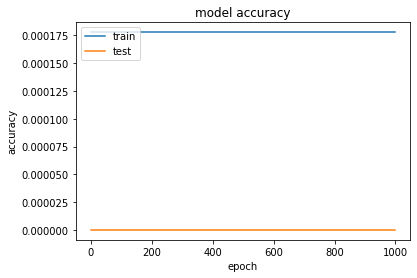

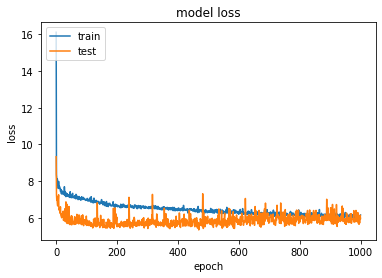

In [ ]:
#1D CNN
#Import the libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numpy import hstack
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", header=0)
#print(dataset.head())
dataset_x = dataset[['CO', ' PM10', ' NO', ' NO2']].values
#dataset_x = dataset.drop(['End Date', 'End Time', ' PM25'], axis=1)
dataset_y = dataset[[' PM25']].values

#Split the dataset into training and testing sets (80%:20%)
x_train,x_test,y_train,y_test=train_test_split(dataset_x, dataset_y, test_size=0.2)

#scaled_ytest = scaler.fit_transform(y_test)

#Convert to numpy arrays
xtrain, ytrain = np.array(x_train), np.array(y_train)

#Reshape the data into 3-D array
scaled_x = np.reshape(xtrain, (xtrain.shape[0],xtrain.shape[1], 1))
scaled_y = np.reshape(ytrain, (ytrain.shape[0],ytrain.shape[1], 1))

# define model
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(scaled_x.shape[1], 1)))
model_cnn.add(MaxPooling1D(pool_size=2))
model_cnn.add(Flatten())
model_cnn.add(Dense(100, activation='relu'))
model_cnn.add(Dense(1))
model_cnn.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
# fit model
cnn_history = model_cnn.fit(scaled_x, scaled_y, epochs=1000, verbose=1, validation_split=0.20)
#Convert x_test to a numpy array 
x_test = np.array(x_test)



#Reshape the data into 3-D array
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
#check predicted values
predictions = model_cnn.predict(x_test, verbose=0)
x_pred = model_cnn.predict(scaled_x, verbose=0)

#Calculate RMSE score
rmse_test=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse_train=np.sqrt(np.mean(((x_pred- y_train)**2)))
print("training rmse: ", rmse_train)
print("testing rmse: ", rmse_test)

# list all data in history
print(cnn_history.history.keys())
print("\n")

# summarize history for accuracy
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# summarize history for loss
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

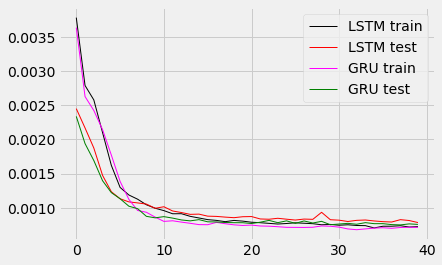

In [ ]:
from matplotlib import pyplot
pyplot.plot(lstm_history.history['loss'], label='LSTM train', color='black', linewidth=1)
pyplot.plot(lstm_history.history['val_loss'], label='LSTM test', color= 'red', linewidth=1)
pyplot.plot(gru_history.history['loss'], label='GRU train', color='magenta', linewidth=1)
pyplot.plot(gru_history.history['val_loss'], label='GRU test', color='green', linewidth=1)
#pyplot.plot(cnn_history.history['loss'], label='CNN train', color='brown', linewidth=2)
#pyplot.plot(cnn_history.history['val_loss'], label='CNN test', color='purple', linewidth=2)
pyplot.legend()
pyplot.show()